<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_DeepDive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta

In [ ]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
#import pandas_ta as ta
import numpy as np
import time
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
import matplotlib.dates as mdates

import ta
print("Libraries Installed!")

0.2.66
Libraries Installed!


# Monthly Win-rate for SP500

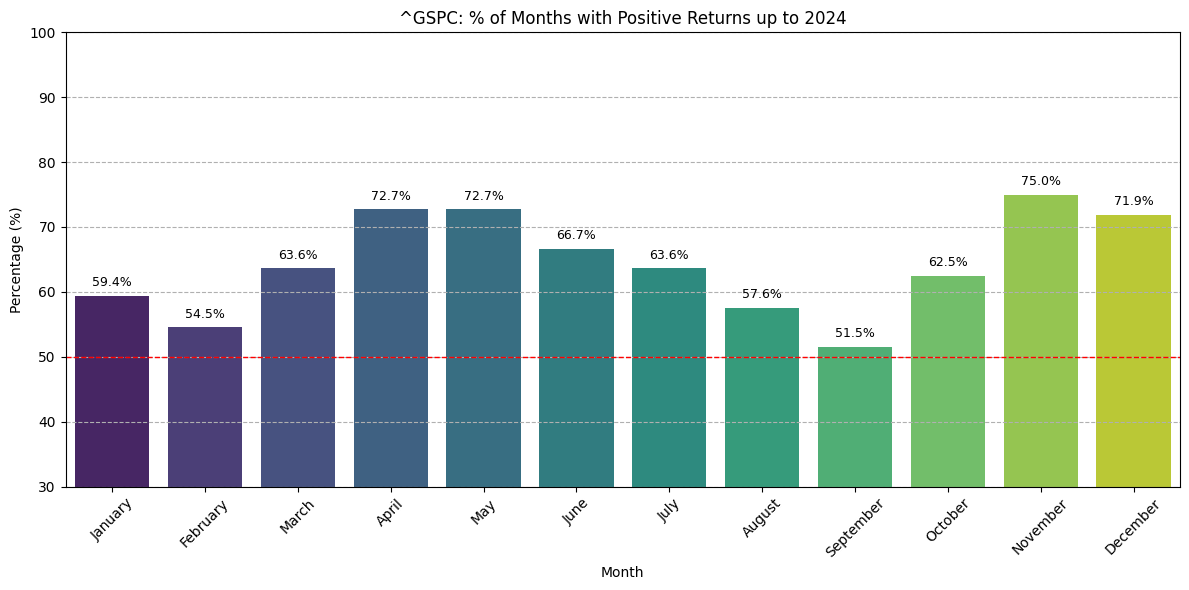

In [ ]:
# Step 1: Download SPY historical data
ticker= '^GSPC' # '^DJI', '^IXIC'
spy = yf.download(ticker, start="1993-01-01", end="2025-09-30", progress=False,auto_adjust=False)

# Step 2: Resample to monthly data and calculate returns
spy_monthly = spy['Close'].resample('ME').last()
monthly_returns = spy_monthly.pct_change().dropna()


# Step 3: Extract month names and whether return was positive
monthly_returns.columns = ['Return']
monthly_returns_df = monthly_returns.copy()
monthly_returns_df['Month'] = monthly_returns_df.index.month_name()
monthly_returns_df['Positive'] = monthly_returns_df['Return'] > 0


# Step 4: Group by month and calculate percent positive
positive_rate = (
    monthly_returns_df.groupby('Month')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Step 5: Order months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
positive_rate['Month'] = pd.Categorical(positive_rate['Month'], categories=month_order, ordered=True)
positive_rate = positive_rate.sort_values('Month')

# Step 6: Plot using Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=positive_rate,
    x='Month',
    y='Percent Positive',
    hue='Month',
    palette='viridis',
    legend=False
)

# Annotate each bar with the exact value
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )
# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')
plt.xticks(rotation=45)
plt.title("{}: % of Months with Positive Returns up to 2024".format(ticker))
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()


#monthly_returns_df.head()

Days of Week

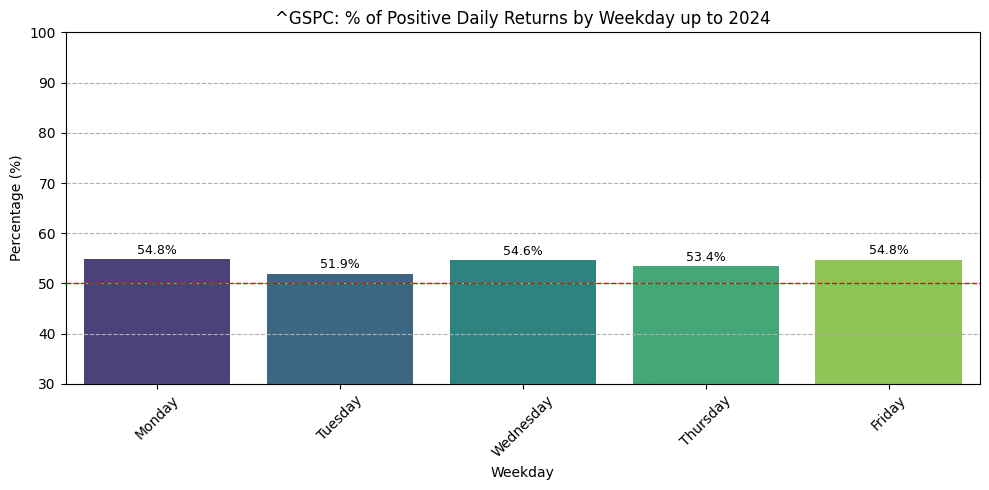

In [ ]:
# Step 1: Download SPY historical data
spy = yf.download(ticker, start="1993-01-01", end="2025-09-30", progress=False,auto_adjust=False)

# Step 2: calculate daily returns
spy['Return'] = spy['Close'].pct_change()
spy = spy.dropna()


# Step 3: Add weekday column
spy['Weekday'] = spy.index.day_name()
spy['Positive'] = spy['Return'] > 0



# Step 4: Group by weekday and calculate percentage of positive returns
positive_rate_weekday = (
    spy.groupby('Weekday')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Ensure days are in Monday–Friday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
positive_rate_weekday['Weekday'] = pd.Categorical(
    positive_rate_weekday['Weekday'], categories=weekday_order, ordered=True
)
positive_rate_weekday = positive_rate_weekday.sort_values('Weekday')

# Step 5: Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=positive_rate_weekday,
    x='Weekday',
    y='Percent Positive',
    hue='Weekday',
    palette='viridis',
    legend=False
)

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')

# Customize axes and layout
plt.title("{}: % of Positive Daily Returns by Weekday up to 2024".format(ticker))
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()

#spy.head()

# IWM daily positivit expentacy

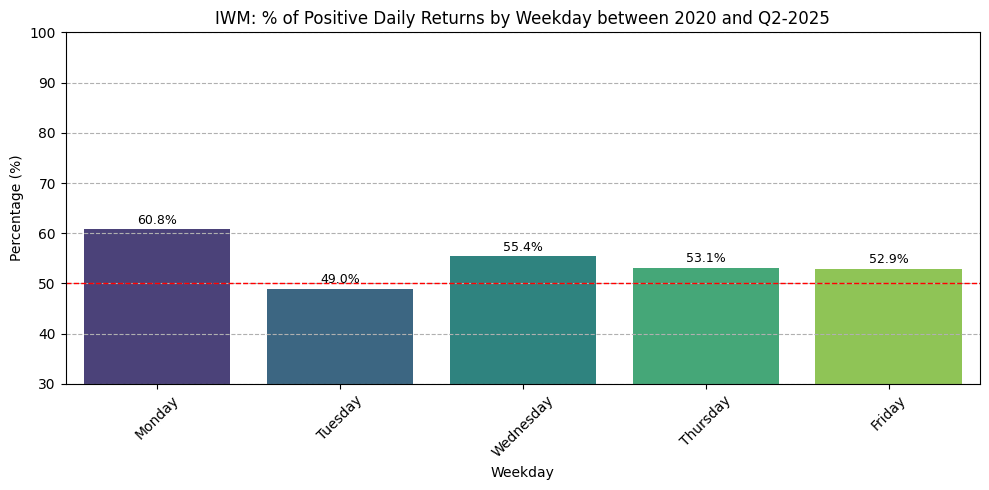

In [ ]:
# Step 1: Download SPY historical data
ticker2= 'IWM'
iwm = yf.download(ticker2, start="2020-01-01", end="2025-09-30", progress=False,auto_adjust=False)

# Step 2: calculate daily returns
iwm['Return'] = spy['Close'].pct_change()
iwm = iwm.dropna()


# Step 3: Add weekday column
iwm['Weekday'] = iwm.index.day_name()
iwm['Positive'] = iwm['Return'] > 0



# Step 4: Group by weekday and calculate percentage of positive returns
positive_rate_weekday = (
    iwm.groupby('Weekday')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Ensure days are in Monday–Friday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
positive_rate_weekday['Weekday'] = pd.Categorical(
    positive_rate_weekday['Weekday'], categories=weekday_order, ordered=True
)
positive_rate_weekday = positive_rate_weekday.sort_values('Weekday')

# Step 5: Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=positive_rate_weekday,
    x='Weekday',
    y='Percent Positive',
    hue='Weekday',
    palette='viridis',
    legend=False
)

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')

# Customize axes and layout
plt.title("{}: % of Positive Daily Returns by Weekday between 2020 and Q2-2025".format(ticker2))
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()

#spy.head()

# 4-Year Presidential Cycle

[*********************100%***********************]  1 of 1 completed


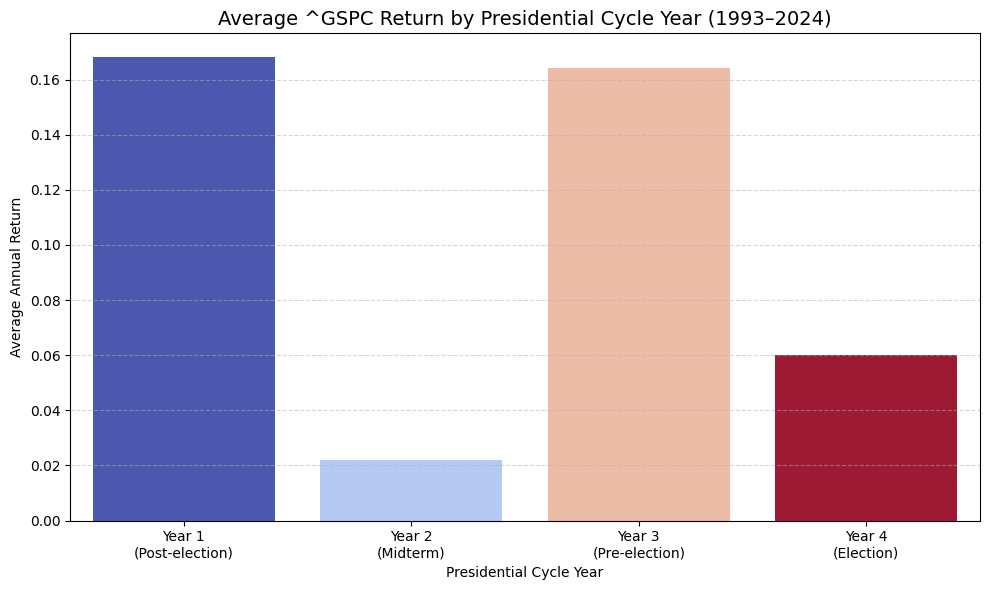

In [ ]:

spy = yf.download(ticker, start="1900-01-01", end="2025-09-30", interval="1mo", auto_adjust=False)
spy['Year'] = spy.index.year

# Step 2: Extract year-end closing prices
yearly_close = spy.groupby('Year')['Close'].last()

# Step 3: Calculate annual returns
yearly_close['Return'] = yearly_close['Close'].pct_change()
yearly_close = yearly_close.dropna().reset_index()

# Step 4: Assign presidential cycle year (1993 = Year 1)
def get_cycle_year(year):
    return ((year - 1993) % 4) + 1

yearly_close['CycleYear'] = yearly_close['Year'].apply(get_cycle_year)

# Step 5: Compute average return by cycle year
cycle_stats = yearly_close.groupby('CycleYear')['Return'].agg(['mean', 'median', 'std', 'count']).reset_index()

# Step 6: Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(
    x='CycleYear',
    y='mean',
    data=cycle_stats,
    hue='CycleYear',            # Assign hue explicitly
    palette='coolwarm',         # Still use the same color palette
    legend=False                # Hide redundant legend
)
plt.title('Average {} Return by Presidential Cycle Year (1993–2024)'.format(ticker), fontsize=14)
plt.xlabel('Presidential Cycle Year')
plt.ylabel('Average Annual Return')
plt.xticks([0, 1, 2, 3], ['Year 1\n(Post-election)', 'Year 2\n(Midterm)', 'Year 3\n(Pre-election)', 'Year 4\n(Election)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Optional: Display table
cycle_stats.round(4)

,CycleYear,mean,median,std,count
0,1,0.1684,0.2144,0.1419,10
1,2,0.0219,0.0493,0.1621,10
2,3,0.1643,0.2188,0.1363,10
3,4,0.0600,0.1097,0.1816,10


[*********************100%***********************]  1 of 1 completed


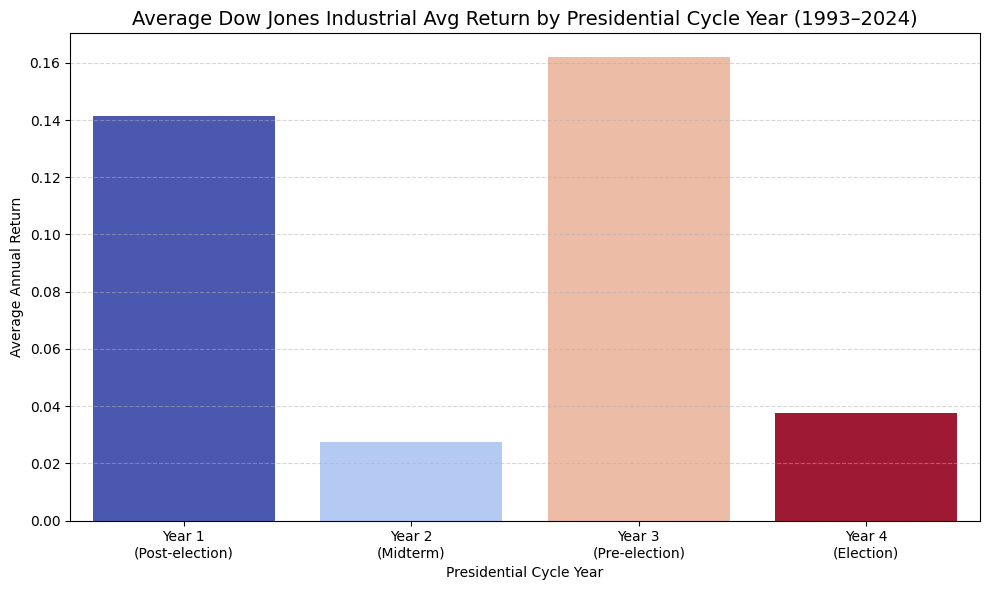

In [ ]:
#Dow Jones Industrial Avg
dji = yf.download("^DJI", start="1993-01-01", end="2025-09-30", interval="1mo", auto_adjust=False)
dji['Year'] = dji.index.year

# Step 2: Extract year-end closing prices
yearly_close = dji.groupby('Year')['Close'].last()

# Step 3: Calculate annual returns
yearly_close['Return'] = yearly_close['Close'].pct_change()
yearly_close = yearly_close.dropna().reset_index()

# Step 4: Assign presidential cycle year (1993 = Year 1)
def get_cycle_year(year):
    return ((year - 1993) % 4) + 1

yearly_close['CycleYear'] = yearly_close['Year'].apply(get_cycle_year)

# Step 5: Compute average return by cycle year
cycle_stats = yearly_close.groupby('CycleYear')['Return'].agg(['mean', 'median', 'std', 'count']).reset_index()

# Step 6: Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(
    x='CycleYear',
    y='mean',
    data=cycle_stats,
    hue='CycleYear',            # Assign hue explicitly
    palette='coolwarm',         # Still use the same color palette
    legend=False                # Hide redundant legend
)
plt.title('Average Dow Jones Industrial Avg Return by Presidential Cycle Year (1993–2024)', fontsize=14)
plt.xlabel('Presidential Cycle Year')
plt.ylabel('Average Annual Return')
plt.xticks([0, 1, 2, 3], ['Year 1\n(Post-election)', 'Year 2\n(Midterm)', 'Year 3\n(Pre-election)', 'Year 4\n(Election)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Weinstien Stages by Week for SP500 (Year 2025)

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers


def rolling_regression_slope(series, window=5):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [

        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
        (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold

    ]
    stages = [2, 4, 1]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=3)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_counts(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            all_data.append(result)

    if not all_data:
        return None

    combined_df = pd.concat(all_data)
    stage_counts = combined_df.groupby(['Week', 'Stage']).size().unstack(fill_value=0)

    return stage_counts, combined_df


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV','Q','SOLS']
    tickers = [item for item in tickers if item not in excluded]

    stage_counts, combined_df = aggregate_stage_counts(tickers)
    print(stage_counts.tail())

Loaded 503 tickers
Stage       1    2    3    4
Week                        
2025-10-20  0  275   75  143
2025-10-27  1  246   97  149
2025-11-03  0  248  111  134
2025-11-10  0  250  116  127
2025-11-17  0  223  141  129


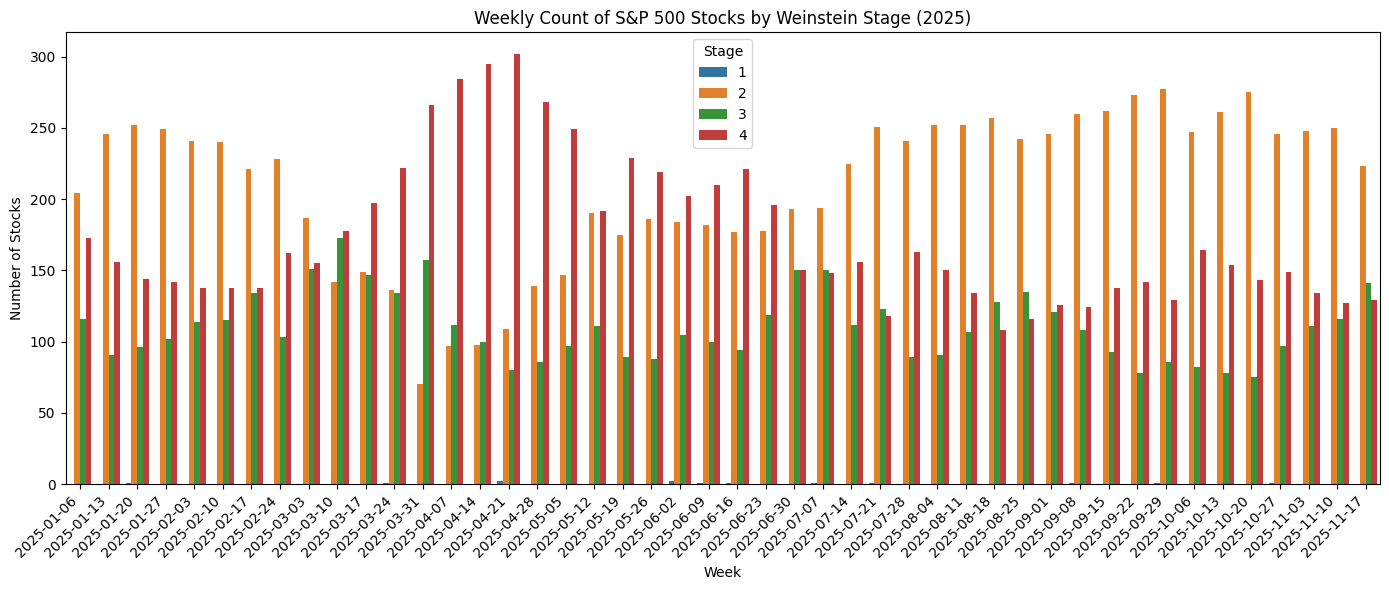

In [ ]:
 # Plot stage distribution by week
plt.figure(figsize=(14, 6))
sns.countplot(data=combined_df, x='Week', hue='Stage', palette='tab10')
plt.title("Weekly Count of S&P 500 Stocks by Weinstein Stage (2025)")
plt.xlabel("Week")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title="Stage")
plt.show()

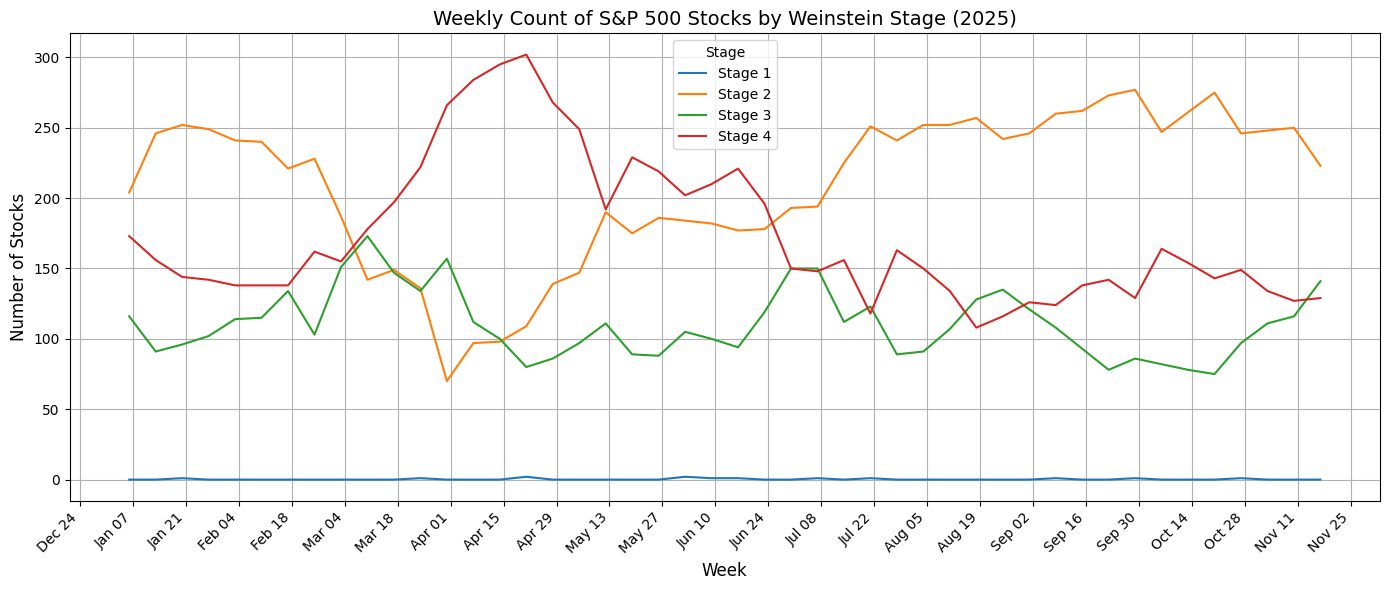

In [ ]:
# plot line chart
stage_counts_reset = stage_counts.reset_index()

plt.figure(figsize=(14, 6))

for stage in stage_counts.columns:
    plt.plot(stage_counts_reset['Week'], stage_counts_reset[stage], label=f"Stage {stage}")

plt.title("Weekly Count of S&P 500 Stocks by Weinstein Stage (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Stocks", fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage")
plt.tight_layout()
plt.grid(True)
plt.show()

#  Percentage distribution of SP500 Stocks by Stage Analysis (Year 2025)

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

def rolling_regression_slope(series, window=5):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
        (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold
    ]

    stages = [2, 4, 1]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=3)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([1,2,3, 4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [1,2,3, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        1: "Basing Stocks",
        2: "Advancing Stocks",
        3: "Topping Stocks",
        4: "Declining Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV','Q','SOLS']
    tickers = [item for item in tickers if item not in excluded]

    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 503 tickers
Stage       Basing Stocks  Advancing Stocks  Topping Stocks  Declining Stocks
Week                                                                         
2025-10-20            0.0             55.78           15.21             29.01
2025-10-27            0.2             49.90           19.68             30.22
2025-11-03            0.0             50.30           22.52             27.18
2025-11-10            0.0             50.71           23.53             25.76
2025-11-17            0.0             45.23           28.60             26.17


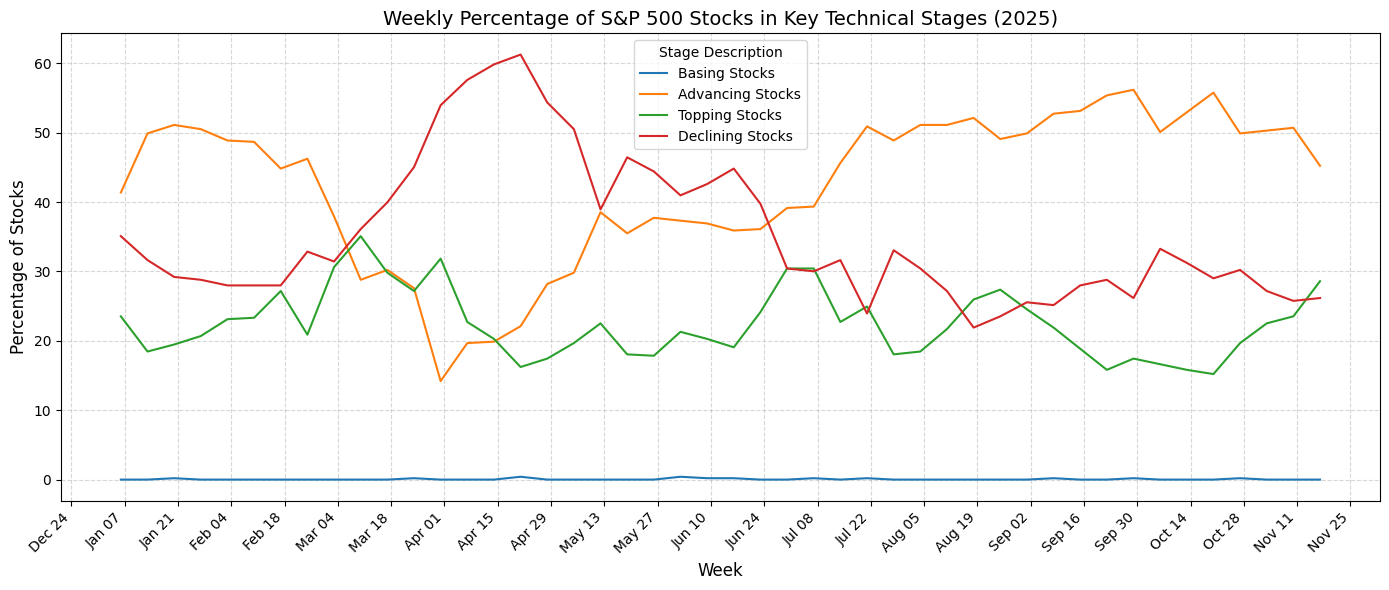

In [ ]:
stage_count_reset = stage_count.reset_index()  # Remove the 'Stage' label
plt.figure(figsize=(14, 6))

# Loop through each descriptive column name (e.g., "Basing or Advancing Stocks")
for stage_label in percentage_df.columns:
    plt.plot(stage_count_reset['Week'], percentage_df[stage_label], label=stage_label)

plt.title("Weekly Percentage of S&P 500 Stocks in Key Technical Stages (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Percentage of Stocks", fontsize=12)

# Format x-axis to show every 2nd week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage Description")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Adavancing  vs Not Adavancing Stage 2025

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

def rolling_regression_slope(series, window=5):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
        (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold
    ]
    stages = [2, 4, 4]

    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=4)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([2,4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [2, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        2: "Advancing Stocks",
        4: "Not Advancing Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV','Q','SOLS']
    tickers = [item for item in tickers if item not in excluded]

    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 503 tickers
Stage       Advancing Stocks  Not Advancing Stocks
Week                                              
2025-10-20             55.78                 44.22
2025-10-27             49.90                 50.10
2025-11-03             50.30                 49.70
2025-11-10             50.71                 49.29
2025-11-17             45.23                 54.77


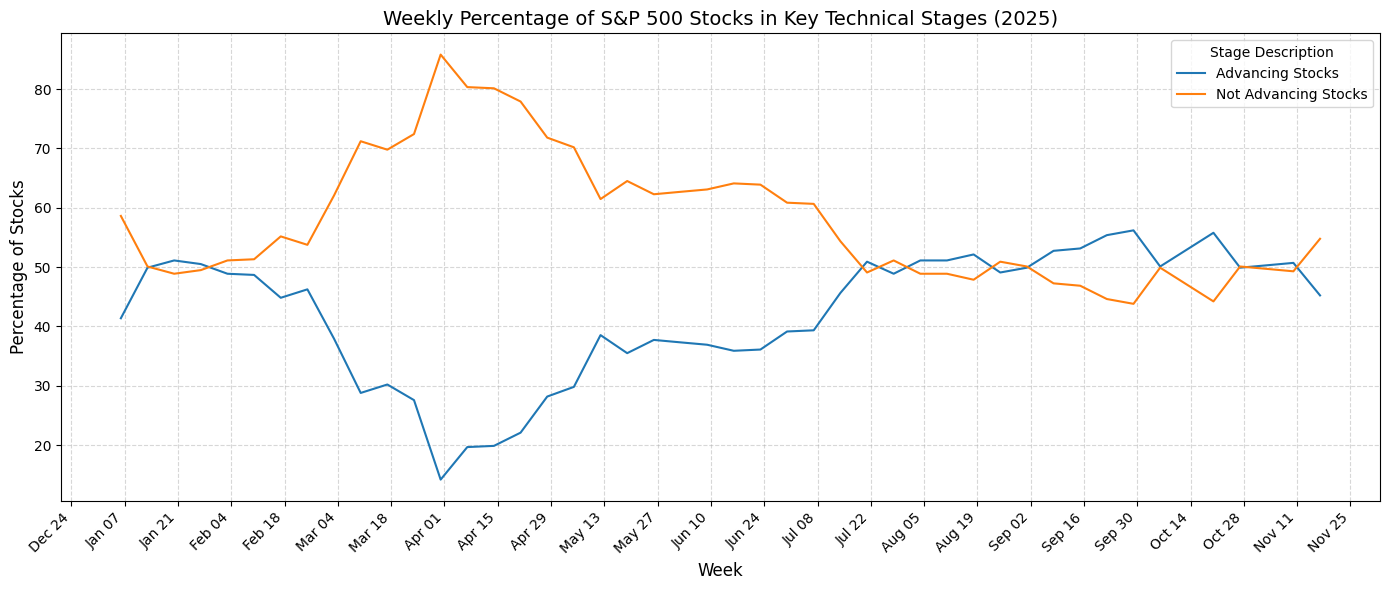

In [ ]:
stage_count_reset = stage_count.reset_index()  # Remove the 'Stage' label
plt.figure(figsize=(14, 6))

# Loop through each descriptive column name (e.g., "Basing or Advancing Stocks")
for stage_label in percentage_df.columns:
    plt.plot(stage_count_reset['Week'], percentage_df[stage_label], label=stage_label)

plt.title("Weekly Percentage of S&P 500 Stocks in Key Technical Stages (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Percentage of Stocks", fontsize=12)

# Format x-axis to show every 2nd week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage Description")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Adavancing  vs Not Adavancing Stage 2024 Vs. 2025

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

def rolling_regression_slope(series, window=5):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
                  (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
                  (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
                  (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold
    ]
    stages = [2, 4, 4]

    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=4)
    # Only keep 2025 data
    #data = data[data.index.year == 2024]
    data = data[data.index.year.isin([2024, 2025])]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([2,4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [2, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        2: "Advancing Stocks",
        4: "Not Advancing Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV','Q','SOLS']
    tickers = [item for item in tickers if item not in excluded]

    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 503 tickers
Stage       Advancing Stocks  Not Advancing Stocks
Week                                              
2025-10-20             55.78                 44.22
2025-10-27             49.90                 50.10
2025-11-03             50.30                 49.70
2025-11-10             50.71                 49.29
2025-11-17             45.23                 54.77


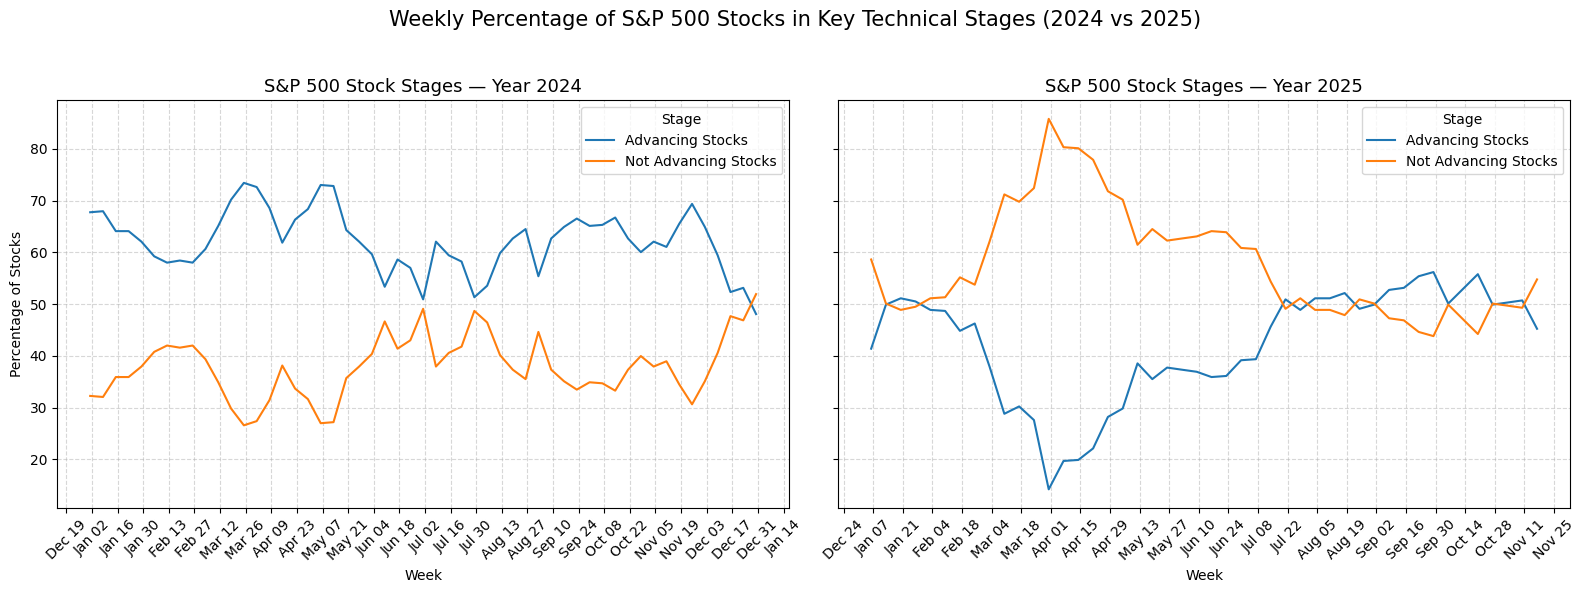

In [ ]:
percentage_dfs = percentage_df.copy()
percentage_dfs['Week'] = percentage_df.index

# Ensure Week is a datetime column
percentage_dfs['Week'] = pd.to_datetime(percentage_dfs['Week'])

# Split the data for 2024 and 2025
data_2024 = percentage_dfs[percentage_dfs['Week'].dt.year == 2024]
data_2025 = percentage_dfs[percentage_dfs['Week'].dt.year == 2025]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ---- Plot for 2024 ----
for stage_label in percentage_df.columns:
    axes[0].plot(data_2024['Week'], data_2024[stage_label], label=stage_label)

axes[0].set_title("S&P 500 Stock Stages — Year 2024", fontsize=13)
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Percentage of Stocks")
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title="Stage", loc='best')  # ✅ auto-placed inside subplot

# ---- Plot for 2025 ----
for stage_label in percentage_df.columns:
    axes[1].plot(data_2025['Week'], data_2025[stage_label], label=stage_label)

axes[1].set_title("S&P 500 Stock Stages — Year 2025", fontsize=13)
axes[1].set_xlabel("Week")
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title="Stage", loc='best')  # ✅ auto-placed inside subplot

# ---- Get unique legend entries ----
handles, labels = axes[1].get_legend_handles_labels()
unique = dict(zip(labels, handles))  # remove duplicates by label

#fig.legend(unique.values(), unique.keys(), title="Stage Description", loc="best", ncol=4)

plt.suptitle("Weekly Percentage of S&P 500 Stocks in Key Technical Stages (2024 vs 2025)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

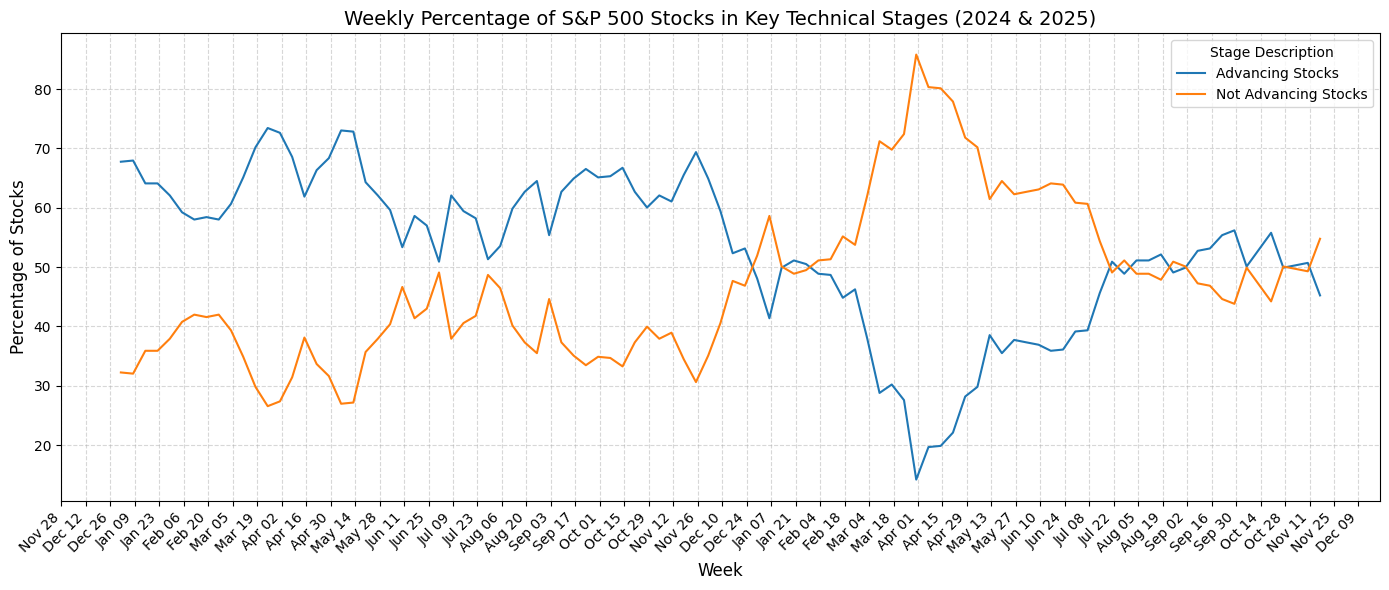

In [ ]:
stage_count_reset = stage_count.reset_index()  # Remove the 'Stage' label
plt.figure(figsize=(14, 6))

# Loop through each descriptive column name (e.g., "Basing or Advancing Stocks")
for stage_label in percentage_df.columns:
    plt.plot(stage_count_reset['Week'], percentage_df[stage_label], label=stage_label)

plt.title("Weekly Percentage of S&P 500 Stocks in Key Technical Stages (2024 & 2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Percentage of Stocks", fontsize=12)

# Format x-axis to show every 2nd week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage Description")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-839630773.py:17: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ytd_pivot = spy.pivot_table(values='YTD_Return', index='Week', columns='Year')


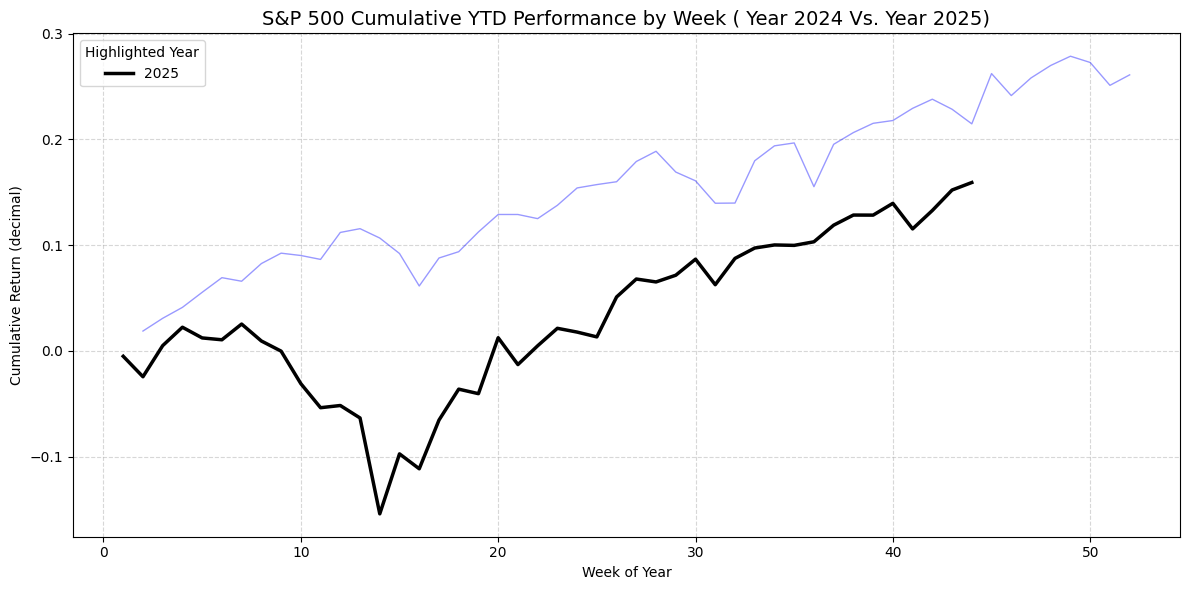

In [ ]:
spy = yf.download("SPY", start="2024-01-01", end="2025-11-01", interval="1wk", auto_adjust=True)
#spy = spy[['Adj Close']].rename(columns={'Adj Close': 'Close'})
spy.dropna(inplace=True)

spy['Return'] = spy['Close'].pct_change()

iso_calendar = spy.index.isocalendar()
spy['Year'] = iso_calendar['year']
spy['Week'] = iso_calendar['week']

#spy['Year'] = spy.index.year
#spy['Week'] = spy.index.isocalendar().week

# Compute cumulative YTD return within each year
spy['YTD_Return'] = spy.groupby('Year')['Return'].cumsum()

ytd_pivot = spy.pivot_table(values='YTD_Return', index='Week', columns='Year')


latest_year = ytd_pivot.columns.max()

plt.figure(figsize=(12, 6))

# Plot all other years faintly
for year in ytd_pivot.columns:
    plt.plot(
        ytd_pivot.index,
        ytd_pivot[year],
        color='blue',
        alpha=0.4,
        linewidth=1,
    )

# ✅ Highlight the latest year (automatically)
plt.plot(
    ytd_pivot.index,
    ytd_pivot[latest_year],
    linewidth=2.5,
    color='black',
    label=f"2025"
    #label=f"{latest_year} (current)"
)

plt.title("S&P 500 Cumulative YTD Performance by Week ( Year 2024 Vs. Year 2025)", fontsize=14)
plt.xlabel("Week of Year")
plt.ylabel("Cumulative Return (decimal)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Highlighted Year", loc='best')
plt.tight_layout()
plt.show()

# Optimum percentage of stock advancing from SP500

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

def rolling_regression_slope(series, window=5):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
        (data['SMA_slope'].abs() <= 0.001)
    ]
    stages = [2, 4, 4]

    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=4)
    # Only keep 2025 data
    #data = data[data.index.year == 2025]
    data = data[data['Week'].dt.year.isin([2024, 2025])]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([2,4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [2, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        2: "Advancing Stocks",
        4: "Not Advancing Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]

    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 503 tickers
Not enough data for Q
Not enough data for SOLS
Stage       Advancing Stocks  Not Advancing Stocks
Week                                              
2025-10-20             55.67                 44.33
2025-10-27             49.70                 50.30
2025-11-03             50.10                 49.90
2025-11-10             50.51                 49.49
2025-11-17             45.05                 54.95


In [ ]:
#stage_count.tail()
weekly_advancing= percentage_df.reset_index()  # Move 'Week' from index to a column
weekly_advancing= weekly_advancing[['Week','Advancing Stocks'] ].copy()
weekly_advancing.loc[:,'Advancing Stocks'] =weekly_advancing['Advancing Stocks']/100
weekly_advancing.head()

Stage,Week,Advancing Stocks
0,2024-01-01,0.6775
1,2024-01-08,0.6795
2,2024-01-15,0.6410
3,2024-01-22,0.6410
4,2024-01-29,0.6207


In [ ]:
# Download weekly SPY data directly
spy = yf.download("SPY", period="2y", interval="1wk", progress=False,auto_adjust=False)

# Calculate weekly returns in decimal form
spy['sp500_return'] = spy['Adj Close'].pct_change()

# Create the final DataFrame
df_returns = spy[['sp500_return']].reset_index().rename(columns={'Date': 'Week'})

# Drop the first NaN return
df_returns= df_returns.dropna().reset_index(drop=True)


# Flatten column names
df_returns.columns = [col[0] for col in df_returns.columns]  # keep only the first level

# Optional: rename to match your intended structure
df_returns= df_returns.rename(columns={'Week': 'Week', 'sp500_return': 'sp500_return'})
df_returns.head()



,Week,sp500_return
0,2023-11-27,0.008346
1,2023-12-04,0.002396
2,2023-12-11,0.019839
3,2023-12-18,0.013296
4,2023-12-25,0.003505


In [ ]:
weekly_data = pd.merge(weekly_advancing, df_returns, on='Week', how='inner')
weekly_data.head()

,Week,Advancing Stocks,sp500_return
0,2024-01-01,0.6775,-0.015548
1,2024-01-08,0.6795,0.018721
2,2024-01-15,0.6410,0.012063
3,2024-01-22,0.6410,0.010323
4,2024-01-29,0.6207,0.014239


In [ ]:
# Step 3: Analyze threshold using percentiles
# Choose percentiles for historical long/short signals
long_percentile = 70  # e.g., top 30% advancing weeks
short_percentile = 30 # e.g., bottom 30% advancing weeks

long_threshold = np.percentile(weekly_data['Advancing Stocks'], long_percentile)
short_threshold = np.percentile(weekly_data['Advancing Stocks'], short_percentile)

# Step 8: Analyze correlation or thresholds
corrs = weekly_data['Advancing Stocks'].corr(weekly_data['sp500_return'])
print(f"Correlation between % advancing stocks and SP500 return: {corrs:.3f}")

print(f"Data-driven thresholds:")
print(f"Go long if Advancing_pct >= {long_threshold:.2f}")
print(f"Consider short/avoid if Advancing_pct <= {short_threshold:.2f}")

Correlation between % advancing stocks and SP500 return: 0.138
Data-driven thresholds:
Go long if Advancing_pct >= 0.62
Consider short/avoid if Advancing_pct <= 0.50


In [ ]:
# Optional: Check historical returns above/below threshold
avg_return_long = weekly_data[weekly_data['Advancing Stocks'] >= long_threshold]['sp500_return'].mean()
avg_return_short = weekly_data[weekly_data['Advancing Stocks'] <= short_threshold]['sp500_return'].mean()

print(f"Average SP500 return for long weeks: {avg_return_long:.4f}")
print(f"Average SP500 return for short weeks: {avg_return_short:.4f}")

Average SP500 return for long weeks: 0.0097
Average SP500 return for short weeks: -0.0001


# Percentage of SP500 stocks above 50MA

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers



# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_above50MA(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="2y", interval="1d", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_50'] = data['Close'].rolling(window=50).mean()
    # Backfill missing values
    data = data.bfill()
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_50'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        data['Price_Below_SMA'] ,
        data['Price_Above_SMA'] ]
    stages = [0,1]

    #data['Week'] = data.index.to_period("D").start_time # data.index.to_period('W').astype(str)
    data['Week'] = data.index

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    #data = data[data.index.year == 2025]
    data = data[data['Week'].dt.year.isin([2024, 2025])]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_above50MA(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([0,1])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [0, 1]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        1: "Above 50 SMA",
        0: "Below 50 SMA"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV','Q','SOLS']
    tickers = [item for item in tickers if item not in excluded]

    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 503 tickers
Stage       Below 50 SMA  Above 50 SMA
Week                                  
2025-11-17         63.49         36.51
2025-11-18         64.30         35.70
2025-11-19         65.72         34.28
2025-11-20         69.17         30.83
2025-11-21         61.46         38.54


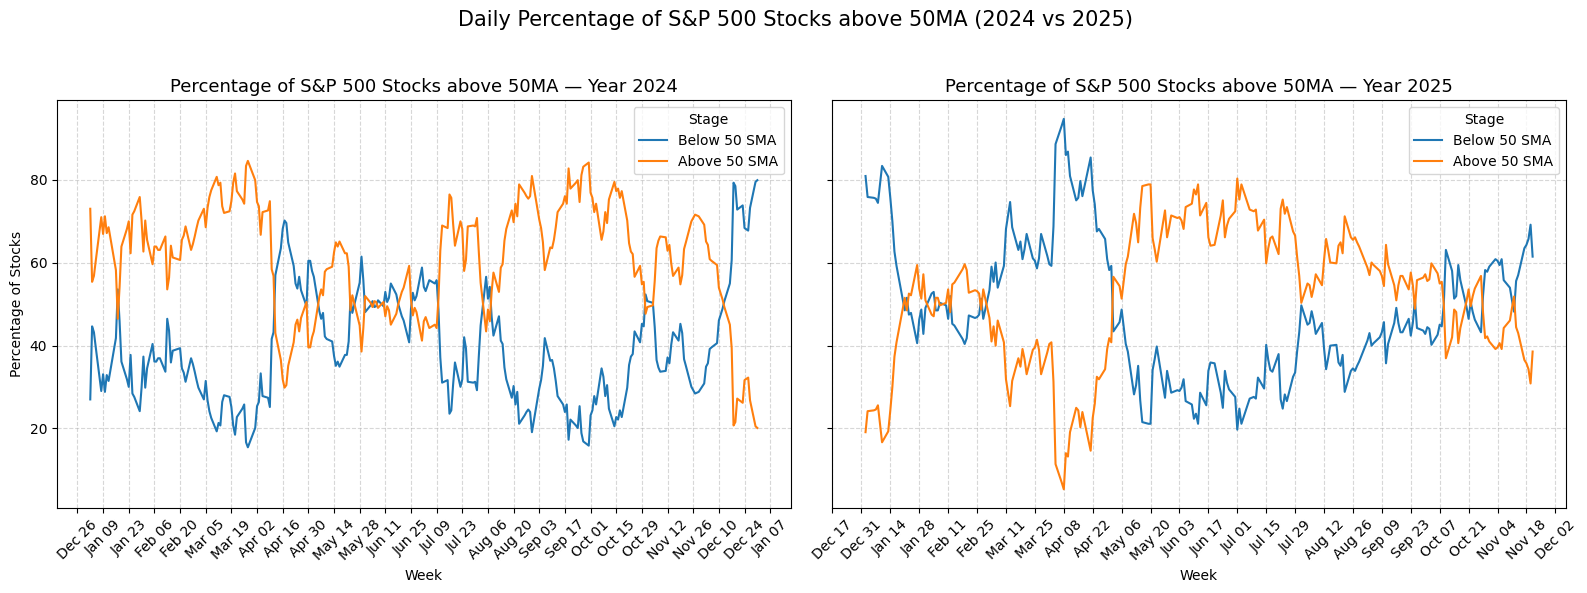

In [ ]:
percentage_dfs = percentage_df.copy()
percentage_dfs['Week'] = percentage_df.index

# Ensure Week is a datetime column
percentage_dfs['Week'] = pd.to_datetime(percentage_dfs['Week'])

# Split the data for 2024 and 2025
data_2024 = percentage_dfs[percentage_dfs['Week'].dt.year == 2024]
data_2025 = percentage_dfs[percentage_dfs['Week'].dt.year == 2025]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ---- Plot for 2024 ----
for stage_label in percentage_df.columns:
    axes[0].plot(data_2024['Week'], data_2024[stage_label], label=stage_label)

axes[0].set_title("Percentage of S&P 500 Stocks above 50MA — Year 2024", fontsize=13)
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Percentage of Stocks")
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title="Stage", loc='best')  # ✅ auto-placed inside subplot

# ---- Plot for 2025 ----
for stage_label in percentage_df.columns:
    axes[1].plot(data_2025['Week'], data_2025[stage_label], label=stage_label)

axes[1].set_title("Percentage of S&P 500 Stocks above 50MA — Year 2025", fontsize=13)
axes[1].set_xlabel("Week")
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title="Stage", loc='best')  # ✅ auto-placed inside subplot

# ---- Get unique legend entries ----
handles, labels = axes[1].get_legend_handles_labels()
unique = dict(zip(labels, handles))  # remove duplicates by label

#fig.legend(unique.values(), unique.keys(), title="Stage Description", loc="best", ncol=4)

plt.suptitle("Daily Percentage of S&P 500 Stocks above 50MA (2024 vs 2025)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
daily_pct= percentage_df.reset_index()  # Move 'Week' from index to a column
daily_pct= daily_pct[['Week','Above 50 SMA'] ].copy()
daily_pct.loc[:,'Above 50 SMA'] =daily_pct['Above 50 SMA']/100

daily_pct.head()

Stage,Week,Above 50 SMA
0,2024-01-02,0.7302
1,2024-01-03,0.5538
2,2024-01-04,0.5680
3,2024-01-05,0.6045
4,2024-01-08,0.7099


In [ ]:
# Step 6: Get SPY weekly returns
spy = yf.download("SPY", period="2y", interval="1d", auto_adjust=True)
spy['sp500_return'] = spy['Close'].pct_change()
spy = spy.reset_index().rename(columns={'Date': 'Week'})
# Drop the first NaN return
spy= spy.dropna().reset_index(drop=True)


# Flatten column names
spy.columns = [col[0] for col in spy.columns]  # keep only the first level

# Optional: rename to match your intended structure
spy= spy.rename(columns={'Week': 'Week', 'sp500_return': 'sp500_return'})

# Step 7: Merge

#stage_count.tail()


daily_data = pd.merge(daily_pct, spy[['Week', 'sp500_return']], on='Week', how='inner')

# Step 8: Analyze correlation or thresholds
corr = daily_data['Above 50 SMA'].corr(daily_data['sp500_return'])
print(f"\nCorrelation between % above 50MA and SP500 return: {corr:.3f}")

# Optional threshold test (like before)
long_thresh = np.percentile(daily_data['Above 50 SMA'], 70)
short_thresh = np.percentile(daily_data['Above 50 SMA'], 30)

avg_long = daily_data[daily_data['Above 50 SMA'] >= long_thresh]['sp500_return'].mean()
avg_short = daily_data[daily_data['Above 50 SMA'] <= short_thresh]['sp500_return'].mean()

print(f"\nGo long if pct_above_50ma >= {long_thresh:.2f}")
print(f"Go short if pct_above_50ma <= {short_thresh:.2f}")
print(f"Avg SP500 return for long days: {avg_long:.4f}")
print(f"Avg SP500 return for short days: {avg_short:.4f}")

[*********************100%***********************]  1 of 1 completed


Correlation between % above 50MA and SP500 return: 0.146

Go long if pct_above_50ma >= 0.66
Go short if pct_above_50ma <= 0.50
Avg SP500 return for long days: 0.0025
Avg SP500 return for short days: -0.0013


 ## Filter stocks by stages 2 and 4

# Confirm Stages by Week

In [ ]:
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers


def rolling_regression_slope(series, window=5):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)


def classify_stages_weekly(ticker):


    data = yf.download(ticker, period="2y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        return None

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()
    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    conditions = [
                  (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
                  (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
                  (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold
    ]
    stages = [2, 4, 1]

    data['Stage'] = np.select(conditions, stages, default=3)
    #data = data.dropna(subset=['Stage'])

    # Filter for 2025 only
    data = data[data.index.year == 2025]
    if data.empty:
        return None

    latest = data.iloc[-1]
    return pd.DataFrame({
        'Ticker': [ticker],
        'Week': [latest.name.strftime('%Y-%m-%d')],
        'Stage': [int(latest['Stage'].iloc[0]) if isinstance(latest['Stage'], pd.Series) else int(latest['Stage'])]
    })

def get_weekly_stage_screener(tickers):
    results = []
    for ticker in tickers:
        res = classify_stages_weekly(ticker)
        if res is not None:
            results.append(res)

    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame(columns=['Ticker', 'Week', 'Stage'])


if __name__ == "__main__":
    import pandas as pd

    tickers = get_sp500_tickers()
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV','Q','SOLS']
    tickers = [t for t in tickers if t not in excluded]

    screener_df = get_weekly_stage_screener(tickers)
    print("All weekly results (latest 2025):")
    print(screener_df.head())

    # Filter for bullish or bearish trends (Stage 2 and 3)
    filtered_df = screener_df[screener_df['Stage'].isin([2, 4])]
    print(f"\nFiltered (Stage 2 & 4):\n{filtered_df}")

    # Save to CSV
    filtered_df.to_csv("us_weekly_stage_2_4_stocks_2025.csv", index=False)
    print("\nSaved to 'us_weekly_stage_2_4_stocks_2025.csv'")

All weekly results (latest 2025):
  Ticker        Week  Stage
0   NVDA  2025-11-17      2
1   AAPL  2025-11-17      2
2   MSFT  2025-11-17      3
3   GOOG  2025-11-17      2
4  GOOGL  2025-11-17      2

Filtered (Stage 2 & 4):
    Ticker        Week  Stage
0     NVDA  2025-11-17      2
1     AAPL  2025-11-17      2
3     GOOG  2025-11-17      2
4    GOOGL  2025-11-17      2
5     AMZN  2025-11-17      2
..     ...         ...    ...
486    MOS  2025-11-17      4
487    CRL  2025-11-17      2
488     LW  2025-11-17      2
489    LKQ  2025-11-17      4
491    MOH  2025-11-17      4

[352 rows x 3 columns]

Saved to 'us_weekly_stage_2_4_stocks_2025.csv'


# Weinstien Stages by Week for S&P/ASX 200

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp200_tickers():
    df = pd.read_csv('ASX200.csv')
    tickers = df['ticks'].tolist()
    return tickers

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=5).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
       (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
        (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold
    ]
    stages = [2, 4, 1]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=3)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_counts(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            all_data.append(result)

    if not all_data:
        return None

    combined_df = pd.concat(all_data)
    stage_counts = combined_df.groupby(['Week', 'Stage']).size().unstack(fill_value=0)

    return stage_counts, combined_df


# Main
if __name__ == "__main__":
    tickers = get_sp200_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['DNL.AX', 'VGN.AX','SOLDA.AX', 'GGP.AX']
    tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    stage_counts, combined_df = aggregate_stage_counts(tickers)
    print(stage_counts.tail())

Loaded 197 tickers
Not enough data for L1G.AX
Not enough data for RYM.AX
Not enough data for GLF.AX
Stage       1   2   3    4
Week                      
2025-10-20  1  65  84   44
2025-10-27  5  66  70   53
2025-11-03  3  42  87   62
2025-11-10  0  56  56   82
2025-11-17  1  30  58  105


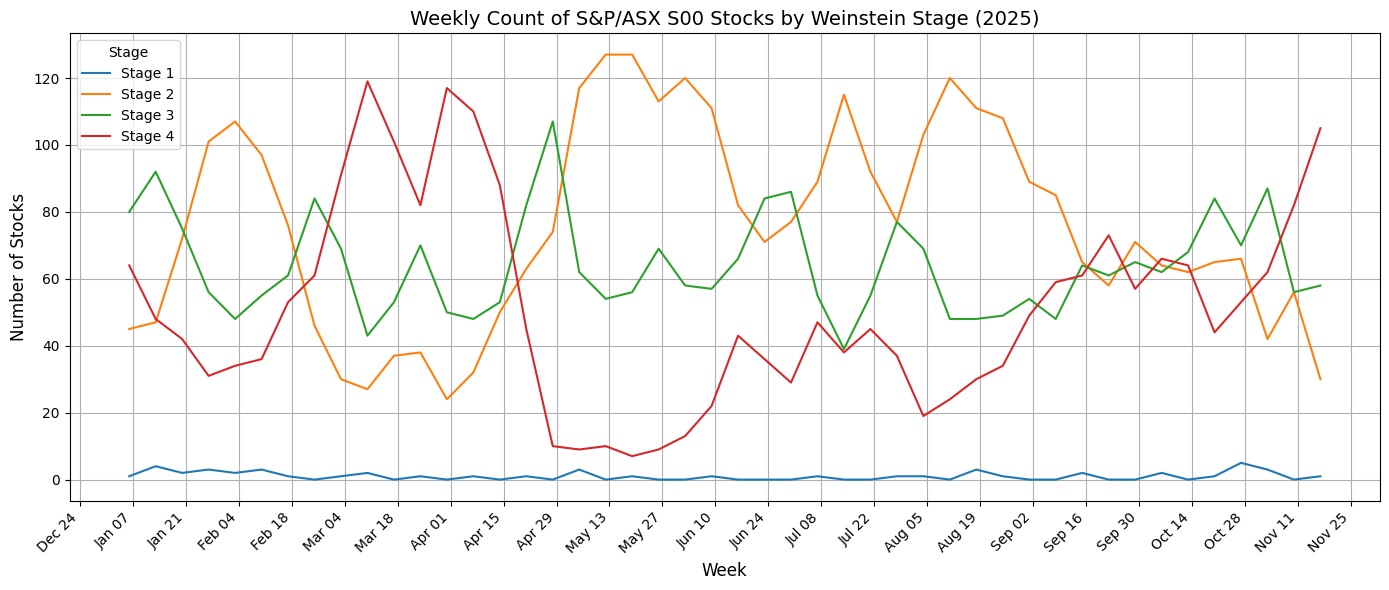

In [ ]:
# plot line chart
stage_counts_reset = stage_counts.reset_index()

plt.figure(figsize=(14, 6))

for stage in stage_counts.columns:
    plt.plot(stage_counts_reset['Week'], stage_counts_reset[stage], label=f"Stage {stage}")

plt.title("Weekly Count of S&P/ASX S00 Stocks by Weinstein Stage (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Stocks", fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage")
plt.tight_layout()
plt.grid(True)
plt.show()

# Combining Stages 1 for S&P/ASX 200 Stocks

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp200_tickers():
    df = pd.read_csv('ASX200.csv')
    tickers = df['ticks'].tolist()
    return tickers

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=5).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
        (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold
    ]
    stages = [2, 4, 4]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=4)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([2, 4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [2, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        2: "Basing or Advancing Stocks",
        4: "Topping or Declining Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp200_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]

    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 197 tickers
Not enough data for GGP.AX
Not enough data for L1G.AX
Not enough data for RYM.AX
Not enough data for VGN.AX
Not enough data for GLF.AX
Stage       Basing or Advancing Stocks  Topping or Declining Stocks
Week                                                               
2025-10-20                       33.50                        66.50
2025-10-27                       33.50                        66.50
2025-11-03                       21.32                        78.68
2025-11-10                       29.44                        70.56
2025-11-17                       15.23                        84.77


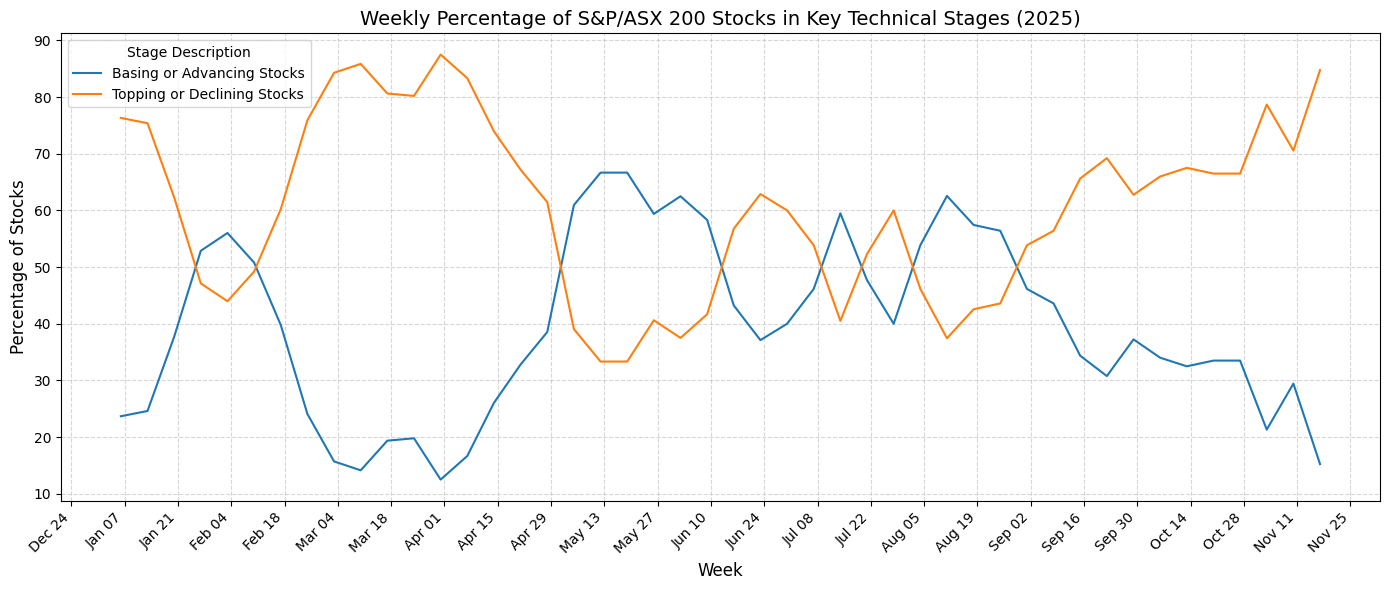

In [ ]:
stage_count_reset = stage_count.reset_index()  # Remove the 'Stage' label
plt.figure(figsize=(14, 6))

# Loop through each descriptive column name (e.g., "Basing or Advancing Stocks")
for stage_label in percentage_df.columns:
    plt.plot(stage_count_reset['Week'], percentage_df[stage_label], label=stage_label)

plt.title("Weekly Percentage of S&P/ASX 200 Stocks in Key Technical Stages (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Percentage of Stocks", fontsize=12)

# Format x-axis to show every 2nd week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage Description")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Confirm ASX200 stocks Stages by Week

In [ ]:
def get_sp200_tickers():
    df = pd.read_csv('ASX200.csv')
    tickers = df['ticks'].tolist()
    return tickers


def rolling_regression_slope(series, window=5):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)


def classify_stages_weekly(ticker):


    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        return None

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'])
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()
    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    conditions = [
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0),
        (data['SMA_slope'].abs() <= 0.001),  # Flat slope threshold
    ]
    stages = [2, 4, 1]

    data['Stage'] = np.select(conditions, stages, default=3)
    #data = data.dropna(subset=['Stage'])

    # Filter for 2025 only
    data = data[data.index.year == 2025]
    if data.empty:
        return None

    latest = data.iloc[-1]
    return pd.DataFrame({
        'Ticker': [ticker],
        'Week': [latest.name.strftime('%Y-%m-%d')],
        'Stage': [int(latest['Stage'].iloc[0]) if isinstance(latest['Stage'], pd.Series) else int(latest['Stage'])]
    })

def get_weekly_stage_screener(tickers):
    results = []
    for ticker in tickers:
        res = classify_stages_weekly(ticker)
        if res is not None:
            results.append(res)

    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame(columns=['Ticker', 'Week', 'Stage'])


if __name__ == "__main__":
    import pandas as pd

    tickers = get_sp200_tickers()
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [t for t in tickers if t not in excluded]

    screener_df = get_weekly_stage_screener(tickers)
    print("All weekly results (latest 2025):")
    print(screener_df.head())

    # Filter for bullish or bearish trends (Stage 2 and 3)
    filtered_df = screener_df[screener_df['Stage'].isin([2, 4])]
    print(f"\nFiltered (Stage 2 & 4):\n{filtered_df}")

    # Save to CSV
    filtered_df.to_csv("asx_weekly_stage_2_4_stocks_2025.csv", index=False)
    print("\nSaved to 'asx_weekly_stage_2_4_stocks_2025.csv'")

All weekly results (latest 2025):
   Ticker        Week  Stage
0  CBA.AX  2025-11-17      3
1  BHP.AX  2025-11-17      3
2  RIO.AX  2025-11-17      2
3  NEM.AX  2025-11-17      2
4  WBC.AX  2025-11-17      2

Filtered (Stage 2 & 4):
     Ticker        Week  Stage
2    RIO.AX  2025-11-17      2
3    NEM.AX  2025-11-17      2
4    WBC.AX  2025-11-17      2
5    NAB.AX  2025-11-17      2
6    ANZ.AX  2025-11-17      2
..      ...         ...    ...
187  NCK.AX  2025-11-17      2
188  CNI.AX  2025-11-17      2
189  GOZ.AX  2025-11-17      2
190  SDR.AX  2025-11-17      2
191  GNC.AX  2025-11-17      2

[123 rows x 3 columns]

Saved to 'asx_weekly_stage_2_4_stocks_2025.csv'
